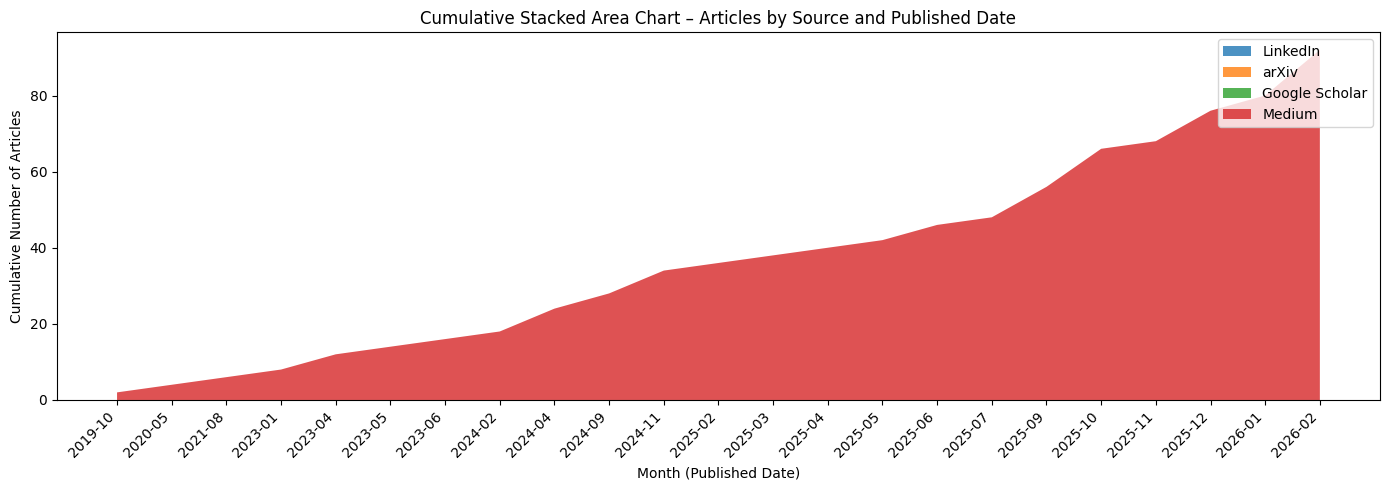

In chart (sum by source): {'LinkedIn': 0.0, 'arXiv': 0.0, 'Google Scholar': 0.0, 'Medium': 92.0}
Total in data: {'LinkedIn': 0, 'arXiv': 0, 'Google Scholar': 0, 'Medium': 92}


In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

with open("data/raw_articles.json", "r", encoding="utf-8") as f:
    all_articles = json.load(f)

sources = [
    ("linkedin", "LinkedIn"),
    ("arxiv", "arXiv"),
    ("google_scholar", "Google Scholar"),
    ("medium", "Medium"),
]

def to_month_key(d):
    if not d or not isinstance(d, str) or d.startswith("NA"):
        return None
    try:
        dt = datetime.strptime(d[:7], "%Y-%m")
        return dt.strftime("%Y-%m")
    except (ValueError, TypeError):
        return None

def is_usable_month_date(source_key, date_str):
    if not date_str or date_str.startswith("NA"):
        return False
    if source_key == "google_scholar" and date_str.endswith("-01-01"):
        return False
    return to_month_key(date_str) is not None

# counts[source_key][month] = count
counts = {sk: defaultdict(float) for sk, _ in sources}
for article in all_articles:
    sk = article.get("source")
    if sk not in counts:
        continue
    date_str = article.get("published_date")
    if is_usable_month_date(sk, date_str):
        month = to_month_key(date_str)
        if month:
            counts[sk][month] += 1

# Scholar year-only (YYYY-01-01): distribute evenly across that year's months
scholar_year_only = defaultdict(int)
for article in all_articles:
    if article.get("source") != "google_scholar":
        continue
    d = article.get("published_date") or ""
    if d.endswith("-01-01") and d[:4].isdigit() and not d.startswith("NA"):
        scholar_year_only[int(d[:4])] += 1

for year, n in scholar_year_only.items():
    months_of_year = [f"{year}-{m:02d}" for m in range(1, 13)]
    per_month = n / 12.0
    for m in months_of_year:
        counts["google_scholar"][m] += per_month

all_months = sorted(set().union(*(set(counts[sk].keys()) for sk, _ in sources)))

# Cumulative stacked area: for each source, running total over months
raw_series = [[counts[sk][m] for m in all_months] for sk, _ in sources]
cumulative_series = [np.cumsum(s) for s in raw_series]
labels = [label for _, label in sources]

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(all_months))
ax.stackplot(x, *cumulative_series, labels=labels, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_months, rotation=45, ha="right")
ax.set_xlabel("Month (Published Date)")
ax.set_ylabel("Cumulative Number of Articles")
ax.set_title("Cumulative Stacked Area Chart – Articles by Source and Published Date")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Scholar: year-only dates (YYYY-01-01) are distributed evenly across the 12 months of that year
in_chart = {label: round(sum(counts[sk].values()), 1) for sk, label in sources}
total = {label: sum(1 for a in all_articles if a.get("source") == sk) for sk, label in sources}
print("In chart (sum by source):", in_chart)
print("Total in data:", total)